## `Assignment-1 `

## Objective

This assignment focuses on advanced pixel-level image manipulation using NumPy, PIL, and OpenCV. The tasks include array-level pixel manipulation, random image cropping, image compositing, grayscale conversion, and custom kernel filtering.


### Step 1: Loading, Inspecting, and Displaying Two Images

In this step, two images are loaded from Google Drive and converted to RGB format. Their dimensions and data types are inspected before displaying them.

Sun shape: (314, 550, 3)
Rose shape: (540, 360, 3)


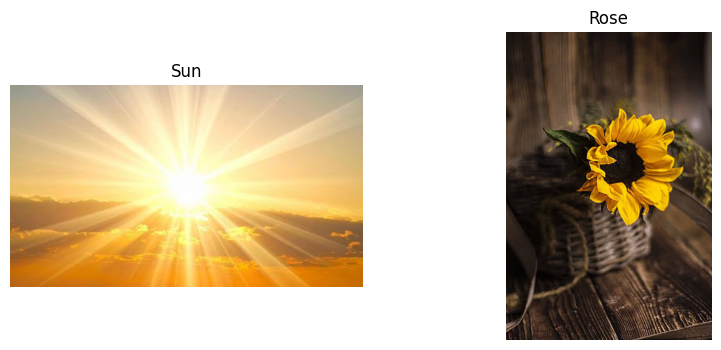

In [15]:
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# GitHub image URLs
sun_url = "https://raw.githubusercontent.com/MashaelAlshehir/Computer-Vision-Final-Project/main/images/sun.jpeg"
rose_url = "https://raw.githubusercontent.com/MashaelAlshehir/Computer-Vision-Final-Project/main/images/rose.jpeg"

# Load Sun image
sun_response = requests.get(sun_url)
sun = np.asarray(
    Image.open(BytesIO(sun_response.content)).convert("RGB")
).copy()

# Load Rose image
rose_response = requests.get(rose_url)
rose = np.asarray(
    Image.open(BytesIO(rose_response.content)).convert("RGB")
).copy()

# Inspect images
print("Sun shape:", sun.shape)
print("Rose shape:", rose.shape)

# Display images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sun)
plt.title("Sun")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rose)
plt.title("Rose")
plt.axis("off")

plt.show()

### Step 2: Manipulating Image Matrices Directly

Images are represented as NumPy arrays. A single pixel can be accessed and modified directly using its row and column coordinates. In this step, one pixel is changed to red.

Original pixel value: [241 211 157]
Modified pixel value: [255   0   0]


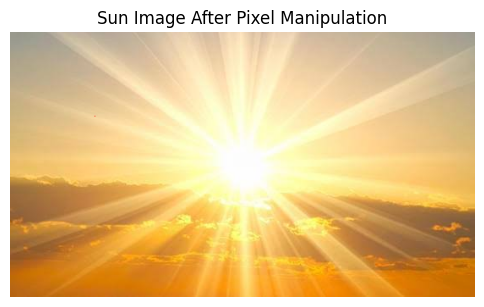

In [16]:
sun_modified = sun.copy()

print("Original pixel value:", sun_modified[100, 100])

sun_modified[100, 100] = [255, 0, 0]

print("Modified pixel value:", sun_modified[100, 100])

plt.figure(figsize=(6, 5))
plt.imshow(sun_modified)
plt.title("Sun Image After Pixel Manipulation")
plt.axis("off")
plt.show()

### Step 3: Random 30×30 Crop and Paste

A 30×30 pixel region is randomly selected from the Sun image and pasted at a random location on the Rose image. The resulting image is named Image3.

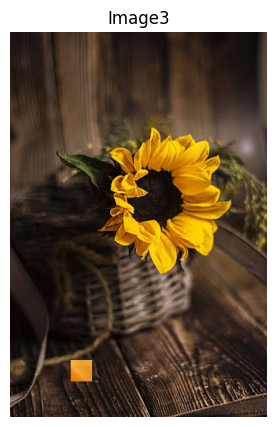

Crop location in Sun: (400, 283)
Paste location in Image3: (85, 460)
Image3 shape: (540, 360, 3)


In [17]:
image3 = rose.copy()

crop_size = 30

sun_h, sun_w = sun.shape[:2]

y1 = np.random.randint(0, sun_h - crop_size + 1)
x1 = np.random.randint(0, sun_w - crop_size + 1)

crop = sun[y1:y1 + crop_size, x1:x1 + crop_size]

img3_h, img3_w = image3.shape[:2]

y2 = np.random.randint(0, img3_h - crop_size + 1)
x2 = np.random.randint(0, img3_w - crop_size + 1)

image3[y2:y2 + crop_size, x2:x2 + crop_size] = crop

plt.figure(figsize=(6, 5))
plt.imshow(image3)
plt.title("Image3")
plt.axis("off")
plt.show()

print("Crop location in Sun:", (x1, y1))
print("Paste location in Image3:", (x2, y2))
print("Image3 shape:", image3.shape)

### Step 4: Converting Images to Grayscale

The Sun, Rose, and Image3 images are converted from RGB to grayscale using OpenCV. A grayscale image contains a single intensity channel instead of three RGB channels.

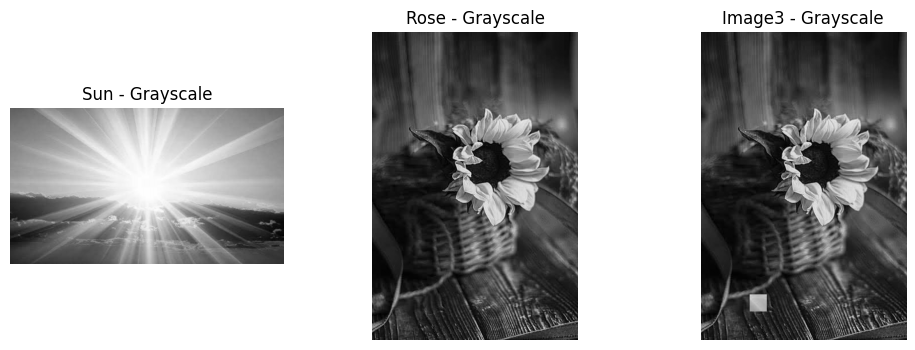

Sun grayscale shape: (314, 550)
Rose grayscale shape: (540, 360)
Image3 grayscale shape: (540, 360)


In [18]:
sun_gray = cv2.cvtColor(sun, cv2.COLOR_RGB2GRAY)
rose_gray = cv2.cvtColor(rose, cv2.COLOR_RGB2GRAY)
image3_gray = cv2.cvtColor(image3, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sun_gray, cmap="gray")
plt.title("Sun - Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rose_gray, cmap="gray")
plt.title("Rose - Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image3_gray, cmap="gray")
plt.title("Image3 - Grayscale")
plt.axis("off")

plt.show()

print("Sun grayscale shape:", sun_gray.shape)
print("Rose grayscale shape:", rose_gray.shape)
print("Image3 grayscale shape:", image3_gray.shape)

### Step 5: Sharpening Image3 Using a Custom Kernel

A custom 3×3 sharpening kernel is applied to the grayscale version of Image3. The kernel enhances local intensity differences, making edges and details more visible.

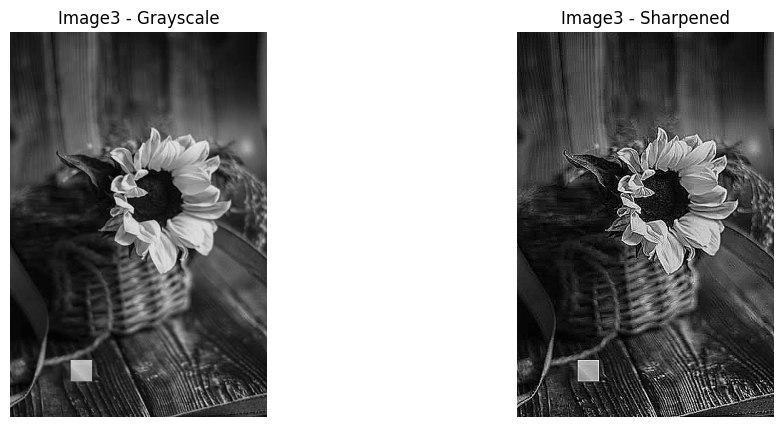

In [19]:
kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

image3_sharpened = cv2.filter2D(
    image3_gray,
    -1,
    kernel
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image3_gray, cmap="gray")
plt.title("Image3 - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image3_sharpened, cmap="gray")
plt.title("Image3 - Sharpened")
plt.axis("off")

plt.show()

## Conclusion

This assignment demonstrated how digital images can be manipulated directly at the pixel and array levels. A random 30×30 region was extracted and transferred between images, the images were converted to grayscale, and a custom sharpening kernel was applied to enhance the edges of Image3.